# 10. Interpretabilitatea modelului final

Modelul final ales este **Gradient Boosting optimizat**, antrenat pe cele mai importante variabile selectate în etapa de feature selection. Deoarece Gradient Boosting este un model neliniar, interpretarea nu se poate face la fel de direct ca în cazul unei regresii liniare, unde analizăm coeficienții.

Din acest motiv, folosim două metode de interpretare:

1. **Feature Importance** — pentru a vedea ce variabile au contribuit cel mai mult la predicții;
2. **SHAP values** — pentru a înțelege mai clar cum influențează fiecare variabilă predicția modelului.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

features_app = [
    'movie_age',
    'log_budget',
    'budget',
    'release_year',
    'vote_count',
    'vote_average',
    'log_popularity',
    'log_vote_count'
]

final_model = joblib.load('../data/final_movie_flop_model.pkl')


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import joblib

# Încărcăm datele
df = pd.read_csv('../data/movies_clean.csv')

# Reconstruim features create anterior
df['log_budget'] = np.log1p(df['budget'])
df['log_vote_count'] = np.log1p(df['vote_count'])
df['log_popularity'] = np.log1p(df['popularity'])

df['movie_age'] = 2026 - df['release_year']
df['is_summer_release'] = df['release_month'].isin([6, 7, 8]).astype(int)
df['is_december_release'] = (df['release_month'] == 12).astype(int)
df['is_long_movie'] = (df['runtime'] > 120).astype(int)

# Aceleași features ca în modelul final
features_app = [
    'movie_age',
    'log_budget',
    'budget',
    'release_year',
    'vote_count',
    'vote_average',
    'log_popularity',
    'log_vote_count'
]

X = df[features_app]
y = df['disappointment_index']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Încărcăm modelul final salvat
final_model = joblib.load('../data/final_movie_flop_model.pkl')

print("Date pregătite pentru interpretabilitate:")
print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")

Date pregătite pentru interpretabilitate:
Train: (692, 8)
Test: (174, 8)


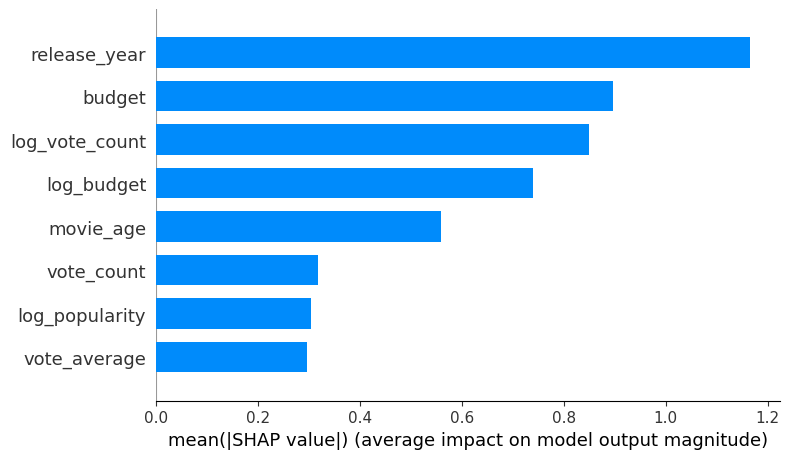

In [13]:
import shap

# Folosim un sample pentru ca SHAP să ruleze mai rapid
X_test_sample = X_test.copy()

# Construim explicatorul SHAP pentru modelul final
explainer = shap.Explainer(final_model, X_train)
shap_values = explainer(X_test_sample)

# Summary plot — importanța globală a variabilelor
shap.summary_plot(shap_values, X_test_sample, plot_type="bar")

### Interpretare SHAP — importanța globală a variabilelor

Graficul SHAP prezintă importanța globală a variabilelor în modelul final. Valorile sunt calculate ca **media valorilor absolute SHAP**, adică impactul mediu al fiecărei variabile asupra predicției modelului, indiferent dacă influența este pozitivă sau negativă.

Cea mai importantă variabilă este **`release_year`**, ceea ce arată că anul lansării are cel mai mare impact asupra estimării Disappointment Index. Acest rezultat sugerează că modelul surprinde diferențe între filmele mai vechi și cele mai recente, probabil din cauza schimbărilor din industrie, bugete, public, marketing și comportamentul consumatorilor.

A doua variabilă importantă este **`budget`**, urmată de **`log_vote_count`** și **`log_budget`**. Acest lucru confirmă că partea financiară și nivelul de vizibilitate al filmului sunt esențiale în estimarea performanței comerciale. Bugetul influențează direct venitul așteptat, iar numărul de voturi reflectă gradul de expunere și interes al publicului.

Variabila **`movie_age`** are și ea o influență relevantă, ceea ce întărește ideea că timpul și contextul lansării contează în performanța unui film. Filmele mai vechi și cele recente pot avea comportamente diferite în date.

Variabilele **`vote_count`**, **`log_popularity`** și **`vote_average`** au o importanță mai redusă, dar tot contribuie la predicție. Acestea reflectă reacția publicului și popularitatea filmului, însă modelul pare să se bazeze mai mult pe anul lansării și pe buget decât pe ratingul mediu.

În concluzie, SHAP confirmă că modelul nu ia decizia pe baza unei singure variabile. Predicția Disappointment Index este influențată în principal de **contextul temporal**, **buget** și **vizibilitatea filmului**, ceea ce este coerent cu logica industriei cinematografice.

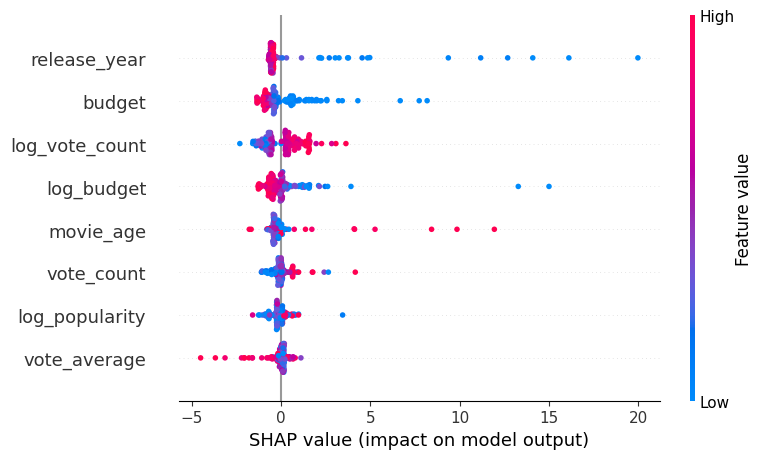

In [14]:
# Summary plot detaliat — direcția influenței variabilelor
shap.summary_plot(shap_values, X_test_sample)

### Interpretare SHAP — direcția influenței variabilelor

Acest grafic SHAP arată nu doar cât de importante sunt variabilele, ci și **direcția influenței lor** asupra predicției modelului. Fiecare punct reprezintă un film din setul de test.

Pe axa orizontală avem valoarea SHAP:
- valori pozitive înseamnă că variabila crește predicția Disappointment Index;
- valori negative înseamnă că variabila scade predicția Disappointment Index.

Culoarea punctelor arată valoarea variabilei:
- albastru = valoare mică;
- roz/roșu = valoare mare.

**`release_year`** are cel mai mare impact asupra modelului. Observăm că valorile mici ale variabilei, adică filmele mai vechi, apar frecvent în partea pozitivă a graficului, ceea ce înseamnă că pot crește predicția DI. În schimb, valorile mari ale variabilei, adică filmele mai recente, sunt mai aproape de zero sau spre zona negativă. Acest rezultat sugerează că modelul diferențiază puternic filmele în funcție de perioada lansării.

**`budget`** și **`log_budget`** influențează semnificativ predicția. Filmele cu bugete mai mici apar de multe ori în zona pozitivă, ceea ce poate indica faptul că unele producții cu buget redus pot avea un DI mai mare decât așteptările inițiale. Bugetele mari nu garantează automat o valoare mare a DI, ceea ce confirmă ideea că investiția ridicată nu asigură succesul relativ.

**`log_vote_count`** are o influență clară: valorile mari ale numărului de voturi tind să împingă predicția în sus. Acest lucru sugerează că filmele cu mai multă vizibilitate și implicare din partea publicului au șanse mai mari să fie asociate cu un Disappointment Index mai ridicat.

**`movie_age`** contribuie și el la predicție, fiind legat de diferențele dintre filmele vechi și cele recente. Punctele sunt răspândite pe ambele părți ale axei, ceea ce arată că efectul acestei variabile nu este strict liniar și depinde de combinația cu celelalte caracteristici.

**`vote_count`**, **`log_popularity`** și **`vote_average`** au un impact mai redus, dar tot contribuie la predicție. În special, ratingul mediu pare să aibă influență mai mică decât bugetul, anul lansării sau numărul de voturi. Asta sugerează că aprecierea publicului nu este suficientă singură pentru a explica performanța comercială relativă.

În concluzie, graficul SHAP confirmă că modelul Gradient Boosting ia decizii pe baza unor relații complexe între variabile. Disappointment Index este influențat în principal de **anul lansării**, **buget**, **vizibilitatea filmului** și **vechimea filmului**, iar efectele nu sunt perfect liniare.

# 11. Concluziile proiectului

## Ce am urmărit în proiect

Scopul proiectului a fost să analizăm performanța financiară a filmelor și să construim un model care poate estima **Disappointment Index**, adică raportul dintre venitul real al unui film și venitul așteptat în funcție de buget.

Am pornit de la ideea că un film nu trebuie judecat doar după venitul total, deoarece un film cu buget foarte mare are nevoie de încasări mult mai mari pentru a fi considerat un succes. De aceea, Disappointment Index este o variabilă mai relevantă decât simplul revenue, deoarece raportează performanța la nivelul investiției.

## Ce am descoperit în analiza exploratorie

În etapa de EDA am observat că distribuțiile financiare sunt foarte asimetrice. Majoritatea filmelor au bugete și venituri moderate, dar există câteva filme extreme care obțin venituri foarte mari sau au bugete foarte ridicate.

Acest lucru arată că industria cinematografică este caracterizată de risc ridicat: multe filme performează modest, în timp ce o parte mică dintre ele generează rezultate excepționale.

O observație importantă este că un buget mare nu garantează automat succesul. Există filme cu bugete mari care nu ating nivelul de venit așteptat, dar și filme cu bugete mai mici care performează mult peste așteptări.

De asemenea, analiza boxploturilor a confirmat existența outlierilor. Acești outlieri nu au fost eliminați din modelul final, deoarece în industria filmului cazurile extreme sunt reale și relevante. Filme precum producțiile cu buget mic și succes masiv pot oferi informații importante despre mecanismele succesului comercial.

## Ce am făcut în etapa de curățare a datelor

În etapa de preprocessing am verificat valorile lipsă și am simulat valori lipsă pentru variabila `runtime`, pentru a demonstra o metodă de tratare a acestora.

Am folosit imputarea cu mediana, deoarece mediana este mai robustă decât media atunci când există valori extreme. Acest lucru este potrivit pentru datele despre filme, unde durata, bugetul și veniturile pot avea distribuții asimetrice.

Am eliminat filmele fără date financiare valide, deoarece variabila țintă, Disappointment Index, nu poate fi calculată fără buget și revenue. După curățare, am rămas cu 866 filme cu date financiare complete.

## Ce modele am testat

În etapa de modelare am comparat mai multe modele:

- OLS simplu;
- OLS cu transformare logaritmică a variabilei țintă;
- OLS cu variabile standardizate;
- Random Forest;
- Gradient Boosting.

Modelele OLS au fost utile pentru interpretare, dar au avut performanță predictivă mai slabă. Acest lucru sugerează că relația dintre caracteristicile unui film și Disappointment Index nu este strict liniară.

Modelele neliniare au performat mai bine. Random Forest a îmbunătățit semnificativ rezultatele față de OLS, iar Gradient Boosting a obținut cea mai bună performanță dintre modelele inițiale.

Modelul final ales a fost **Gradient Boosting optimizat**, deoarece a obținut cel mai bun echilibru între R² și RMSE.

## Ce am obținut prin feature engineering și feature selection

Pentru a îmbunătăți modelul, am construit variabile suplimentare:

- `log_budget`;
- `log_vote_count`;
- `log_popularity`;
- `movie_age`;
- `is_summer_release`;
- `is_december_release`;
- `is_long_movie`.

Aceste variabile au fost create pentru a surprinde mai bine realitatea economică. De exemplu, bugetul și popularitatea au distribuții foarte asimetrice, iar transformările logaritmice reduc efectul valorilor extreme. Variabila `movie_age` permite modelului să distingă între filme vechi și filme recente.

După testare, modelul cu **top 8 features** a avut cea mai bună performanță:

- R² aproximativ 0.516;
- RMSE aproximativ 5.68.

Acest rezultat arată că feature selection a fost utilă. Modelul nu a avut nevoie de toate variabilele disponibile, ci a performat mai bine cu un set mai restrâns și mai relevant de predictori.

## Ce variabile influențează cel mai mult Disappointment Index

Pe baza feature importance și SHAP, cele mai importante variabile pentru predicția Disappointment Index sunt:

- `movie_age`;
- `log_budget`;
- `budget`;
- `release_year`;
- `vote_count`;
- `vote_average`;
- `log_popularity`;
- `log_vote_count`.

Aceste rezultate sugerează că performanța relativă a unui film este influențată de mai multe componente:

1. **componenta financiară** — bugetul filmului;
2. **componenta temporală** — anul lansării și vechimea filmului;
3. **componenta de interes public** — popularitatea și numărul de voturi;
4. **componenta de apreciere** — ratingul mediu.

Prin urmare, succesul sau eșecul financiar nu poate fi explicat printr-o singură variabilă. Modelul confirmă că fenomenul este complex și neliniar.

## Cum poate fi folosit modelul în practică

Modelul poate fi folosit ca instrument orientativ pentru evaluarea riscului comercial al unui film. De exemplu, o companie de producție sau distribuție ar putea introduce caracteristici precum bugetul, durata, anul lansării, popularitatea estimată și nivelul de interes al publicului pentru a obține o estimare a performanței relative.

Modelul nu oferă o predicție perfectă, dar poate sprijini procesul decizional. El poate ajuta la identificarea filmelor cu risc ridicat de performanță sub așteptări și la înțelegerea factorilor care influențează acest risc.

Aplicația web construită în Streamlit transformă modelul într-un instrument ușor de utilizat. Utilizatorul introduce caracteristicile filmului, iar aplicația returnează valoarea estimată a Disappointment Index și o interpretare intuitivă a rezultatului.

## Concluzie finală

Prin acest proiect am parcurs întregul proces de modelare statistică și machine learning: încărcarea datelor, analiza exploratorie, tratarea valorilor lipsă, construirea variabilei țintă, estimarea mai multor modele, feature engineering, feature selection, hiperparametrizare, analiza erorilor, interpretabilitate și implementarea unei aplicații web.

Rezultatul final este un model Gradient Boosting optimizat, care explică aproximativ 52% din variația Disappointment Index pe setul de test. Deși modelul nu este perfect, performanța sa este rezonabilă având în vedere complexitatea industriei cinematografice și caracterul imprevizibil al succesului comercial.

Cea mai importantă concluzie este că succesul financiar al unui film nu depinde doar de buget. Bugetul, anul lansării, popularitatea, numărul de voturi și ratingul publicului contribuie împreună la estimarea performanței relative.

Proiectul arată că modelele neliniare pot surprinde mai bine relațiile complexe din date decât regresia liniară simplă. În același timp, interpretabilitatea rămâne importantă, motiv pentru care am folosit feature importance și SHAP pentru a explica rezultatele modelului.

Aplicația web demonstrează aplicabilitatea practică a modelului și arată cum analiza datelor poate fi transformată într-un instrument de suport decizional pentru industria filmului.